# Phase 4 — STDP & Surrogate-Gradient Deep Dive

This notebook demonstrates two complementary approaches for learning with spiking neural networks:

1. Supervised training using surrogate gradients (backprop through spikes).
2. A local, biologically-inspired pair-based STDP rule for unsupervised weight adaptation (first-layer demo).

The cells are written to be runnable inside the same venv/kernel you used for Phase 3. If you run this in a notebook kernel, set `NUM_WORKERS=0` to avoid pickling issues when transforms are defined inline.

In [1]:
# 1. Imports & device
import os, sys, subprocess, math, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
# SpikingJelly
from spikingjelly.activation_based import neuron, functional, surrogate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True


Device: cuda


In [2]:
# 2. Optional: ensure required packages are installed (uses the active Python executable)
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

REQUIRED = ['numpy', 'matplotlib', 'torch', 'torchvision', 'spikingjelly', 'tqdm']
for pkg in REQUIRED:
    try:
        __import__(pkg.split('[')[0])
    except Exception:
        print('Installing', pkg)
        install(pkg)


## Data & spike-encoding

We use a simple rate encoder (same pattern as Phase 3) to convert MNIST images to spike trains of shape `(T, 784)`.
When running inside a notebook keep `NUM_WORKERS=0` to avoid PicklingError for inline classes.

In [3]:
DATA_DIR = './data'
T_STEPS = 20
BATCH = 64
os.makedirs(DATA_DIR, exist_ok=True)

# Simple SpikeEncoder fallback (fast rate encoder)
class SpikeEncoder:
    def __init__(self, method='rate', T=20):
        self.method = method; self.T = T
    def encode(self, x):
        x = np.clip(x, 0., 1.)
        if self.method == 'rate':
            # x shape (features,) in [0,1] => spike probability per timestep
            return (np.random.rand(self.T, x.size) < x).astype(float)
        else:
            raise NotImplementedError()

class RateEncode:
    def __init__(self, T=20):
        self.enc = SpikeEncoder(method='rate', T=T)
    def __call__(self, img):
        # keep spatial shape for conv layer: return (T, 1, H, W)
        arr = img.numpy()[0]  # (H, W)
        spikes = self.enc.encode(arr.flatten())  # (T, 784)
        spikes = spikes.reshape(spikes.shape[0], 1, 28, 28)
        return torch.FloatTensor(spikes)

transform = transforms.Compose([transforms.ToTensor(), RateEncode(T=T_STEPS)])
train_ds = MNIST(DATA_DIR, train=True, download=True, transform=transform)
test_ds  = MNIST(DATA_DIR, train=False, download=True, transform=transform)

# notebook-safe workers detection
try:
    get_ipython
    IN_IPYTHON = True
except NameError:
    IN_IPYTHON = False
NUM_WORKERS = 0 if IN_IPYTHON else 4

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

sample_spikes, sample_labels = next(iter(train_loader))
print('Batch spike train shape :', sample_spikes.shape)  # (batch, T, 1, 28, 28)


Batch spike train shape : torch.Size([64, 20, 1, 28, 28])


## Supervised training with surrogate gradients

We re-create a small SNN (3 fully-connected layers + `LIFNode`) and train it with surrogate gradients using standard backprop (CrossEntropyLoss on summed spike counts). This is the pragmatic approach for high accuracy.

In [4]:
class SNN(nn.Module):
    def __init__(self, T=20):
        super().__init__()
        self.T = T
        # Conv first layer preserves spatial locality (in_channels=1 -> out_channels=16)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2, bias=False)
        self.lif1 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan(), detach_reset=True)
        # After conv, flatten spatial dimensions for fully-connected layers
        self.fc2 = nn.Linear(16*28*28, 128, bias=False)
        self.lif2 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan(), detach_reset=True)
        self.fc3 = nn.Linear(128, 10, bias=False)
        self.lif3 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan(), detach_reset=True)
    def forward(self, x):
        # x: (batch, T, 1, 28, 28) -> loop over time
        x = x.permute(1, 0, 2, 3, 4)  # (T, batch, C, H, W)
        functional.reset_net(self)
        spike_sum = 0
        for t in range(self.T):
            out = self.conv1(x[t])  # (batch, 16, H, W)
            out = self.lif1(out)    # spike tensor same shape
            out = out.view(out.size(0), -1)  # flatten
            out = self.fc2(out)
            out = self.lif2(out)
            out = self.fc3(out)
            out = self.lif3(out)
            spike_sum = spike_sum + out
        return spike_sum

# Instantiate model
snn_model = SNN(T=T_STEPS).to(DEVICE)
optimizer = torch.optim.Adam(snn_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Quick supervised training loop (1 epoch for demo)
def train_surrogate_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); total_loss=0.; correct=0; total=0
    for spikes, labels in tqdm(loader, desc='Surrogate epoch', leave=False):
        spikes, labels = spikes.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(spikes)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

loss, acc = train_surrogate_one_epoch(snn_model, train_loader, optimizer, criterion, DEVICE)
print(f'Surrogate training demo — Loss: {loss:.4f} | Acc: {acc*100:.2f}%')


Surrogate training demo — Loss: 0.3342 | Acc: 89.11%


## STDP (pair-based) — unsupervised update for first layer

Below is an implementation of a simple pair-based additive STDP rule applied to the first layer weights (`fc1`) of the same SNN architecture. This is intended as an educational experiment: STDP alone (without careful homeostasis/normalization) can diverge, so we include weight clipping and optional weight decay to stabilise learning.

Mechanics (implemented):
- Maintain exponentially-decaying pre- and post-synaptic traces.
- For each timestep, compute weight updates: A_plus * pre_trace_i * post_spike_j - A_minus * pre_spike_i * post_trace_j (outer-product).
- Apply updates to `fc1.weight` and clip to [w_min, w_max].

In [5]:
# STDP helpers (tensorized, supports linear and conv weights)
def stdp_step_linear(weights, pre_spikes, post_spikes, pre_trace, post_trace, A_plus=1e-3, A_minus=1e-3, w_min=0.0, w_max=1.0, lr=1.0):
    # compute outer products across the batch and average (linear layer)
    batch = pre_spikes.size(0)
    pot = torch.matmul(pre_trace.t(), post_spikes) / batch  # (in, out)
    dep = torch.matmul(pre_spikes.t(), post_trace) / batch  # (in, out)
    delta = A_plus * pot - A_minus * dep  # shape (in, out)
    weights.data += lr * delta.t().to(weights.device)
    weights.data.clamp_(w_min, w_max)

def stdp_step_conv(weights, pre_spikes, post_spikes, pre_trace, post_trace, kernel_size=5, padding=2, A_plus=1e-3, A_minus=1e-3, w_min=-1.0, w_max=1.0, lr=1.0):
    # weights: (out_ch, in_ch, kH, kW)
    # pre_spikes: (batch, in_ch, H, W), post_spikes: (batch, out_ch, H, W)
    batch = pre_spikes.size(0)
    # unfold input patches -> (batch, in_ch * kH * kW, L)
    pre_unf = F.unfold(pre_trace, kernel_size=kernel_size, padding=padding)  # using traces for pot
    pre_sp_unf = F.unfold(pre_spikes, kernel_size=kernel_size, padding=padding)
    # post: reshape to (batch, out_ch, L)
    B, out_ch, H, W = post_spikes.size()
    L = pre_unf.size(-1)
    post = post_spikes.view(batch, out_ch, -1)
    post_trace_unf = post_trace.view(batch, out_ch, -1)
    in_dim = pre_unf.size(1)
    out_dim = out_ch
    # accumulate pot and dep across batch
    pot = torch.zeros((in_dim, out_dim), device=weights.device)
    dep = torch.zeros((in_dim, out_dim), device=weights.device)
    for b in range(batch):
        # pre_unf[b]: (in_dim, L), post[b]: (out_ch, L)
        pot += torch.matmul(pre_unf[b], post[b].t())
        dep += torch.matmul(pre_sp_unf[b], post_trace_unf[b].t())
    pot = pot / (batch * L)
    dep = dep / (batch * L)
    delta = A_plus * pot - A_minus * dep  # (in_dim, out_dim)
    # reshape delta -> (out_ch, in_ch, kH, kW)
    delta_t = delta.t().contiguous().view(out_ch, -1)
    delta_w = delta_t.view(out_ch, weights.size(1), kernel_size, kernel_size)
    weights.data += lr * delta_w.to(weights.device)
    weights.data.clamp_(w_min, w_max)


STDP epoch 1/1


STDP batches:   0%|          | 0/938 [00:00<?, ?it/s]

  completed epoch
Finished STDP run


IndexError: index 16 is out of bounds for axis 0 with size 16

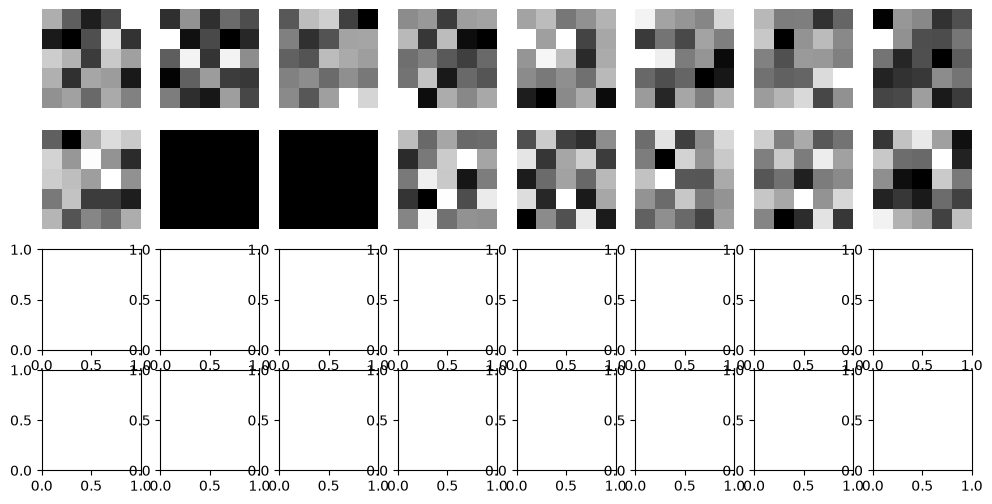

In [ ]:
def run_stdp_unsupervised(model, loader, device, epochs=1, A_plus=1e-2, A_minus=1e-2, tau_pre=20.0, tau_post=20.0, lr=1.0):
    # STDP applied to conv1 weights (conv-first architecture)
    w = model.conv1.weight  # shape (out_ch, in_ch, kH, kW)
    w_min, w_max = -1.0, 1.0
    tau_pre = float(tau_pre); tau_post = float(tau_post)
    alpha_pre = math.exp(-1.0/ tau_pre)
    alpha_post = math.exp(-1.0 / tau_post)
    k = model.conv1.kernel_size[0]
    pad = model.conv1.padding[0]
    for ep in range(epochs):
        print(f'STDP epoch {ep+1}/{epochs}')
        for spikes, _ in tqdm(loader, desc='STDP batches', leave=False):
            # spikes: (batch, T, C, H, W)
            spikes = spikes.to(device)
            batch = spikes.size(0)
            C = spikes.size(2)
            H = spikes.size(3)
            W = spikes.size(4)
            functional.reset_net(model)
            pre_trace = torch.zeros((batch, C, H, W), device=device)
            post_trace = torch.zeros((batch, model.conv1.out_channels, H, W), device=device)
            for t in range(spikes.size(1)):
                pre_sp = spikes[:, t, :, :, :].to(device)  # (batch, C, H, W)
                with torch.no_grad():
                    cur = model.conv1(pre_sp)  # (batch, out_ch, H, W)
                    s = model.lif1(cur)  # (batch, out_ch, H, W)
                    post_sp = s
                pre_trace = alpha_pre * pre_trace + pre_sp
                post_trace = alpha_post * post_trace + post_sp
                stdp_step_conv(w, pre_sp, post_sp, pre_trace, post_trace, kernel_size=k, padding=pad, A_plus=A_plus, A_minus=A_minus, w_min=w_min, w_max=w_max, lr=lr)
        print('  completed epoch')
    print('Finished STDP run')

# Make a fresh model copy (so supervised weights remain separate)
stdp_model = SNN(T=T_STEPS).to(DEVICE)
# initialize weights small
stdp_model.conv1.weight.data.normal_(0, 0.1)
# run a lightweight STDP run
run_stdp_unsupervised(stdp_model, train_loader, DEVICE, epochs=1, A_plus=1e-2, A_minus=5e-3, tau_pre=20.0, tau_post=20.0, lr=1.0)

# Visualize a few receptive fields (conv filters)
W = stdp_model.conv1.weight.data.cpu().numpy()  # (out_ch, in_ch, kH, kW)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    # stop if we've plotted all learned filters (avoid index error)
    if i >= W.shape[0]: break
    # take the single-channel conv filter (in_ch=1)
    img = W[i, 0]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.suptitle('Sample STDP-learned conv filters (conv1)')
plt.show()